# Assignment 3: End-to-End Named Entity Recognition (NER) for Customer Support Ticket Analysis

## Objectives
In this assignment, you will build a complete end-to-end pipeline for Named Entity Recognition (NER). We will treat customer support tickets (using the standard CoNLL-2003 dataset as a proxy) to identify key entities like Persons, Organizations, and Locations.

## Learning Outcomes
By completing this notebook, you will:
1. Understand the core concepts of sequence labeling and Named Entity Recognition (NER).
2. Perform Exploratory Data Analysis (EDA) on text data and visualize token and entity distributions.
3. Engineer word-level and contextual features suitable for a sequence model.
4. Train and evaluate a Conditional Random Field (CRF) model.
5. Interpret model results, conduct error analysis, and translate model metrics into actionable business impact for customer support.

---
**Setup**: Let's first ensure the necessary libraries are installed. Execute the cell below.


In [1]:
!pip install datasets scikit-learn sklearn-crfsuite matplotlib -q


## 1. Introduction to Named Entity Recognition (NER) and CoNLL-2003

### What is Named Entity Recognition (NER)?
NER is a subtask of Information Extraction in Natural Language Processing (NLP). Its goal is to locate and classify named entities mentioned in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, etc.

### Why CoNLL-2003?
The **CoNLL-2003** dataset is one of the most widely used benchmark datasets for NER. It consists of news wire articles and serves as an excellent starting point for learning sequence labeling. Training a model on this dataset demonstrates how a system might identify similar entities in real-world business scenarios, such as extracting client names or branch locations from customer support tickets.

### Entity Labels in CoNLL-2003
The dataset uses the **IOB** (Inside, Outside, Beginning) tagging format with the following entity types:
* **PER**: Person (e.g., *John Doe*)
* **LOC**: Location (e.g., *London*, *Mt. Everest*)
* **ORG**: Organization (e.g., *United Nations*, *Google*)
* **MISC**: Miscellaneous (e.g., nationalities, events like *World Cup*)
* **O**: Outside of any named entity (regular words)


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Set matplotlib style for clean visualiztions
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Task 1: Text Preprocessing and Exploratory Data Analysis (EDA)

### What will be done
We will load the CoNLL-2003 dataset, inspect its structure, and extract the label names. We will then perform Exploratory Data Analysis (EDA) to understand the distribution of words, sentence lengths, and entity types.

### Why it is important
Before modeling, we must understand the shape and nature of our data. Knowing the vocabulary size, sequence lengths, and class imbalances (e.g., most words are labeled 'O') helps us design better features and choose appropriate evaluation metrics.

### Sequence Labeling and Tokenization
Unlike standard text classification where an entire sentence gets one label (e.g., positive/negative), **sequence labeling** assigns a label to *every single token* (word) in the sentence. **Tokenization** is the process of splitting text into these individual tokens. If tokenization is flawed, our entity boundaries will be incorrect.


In [3]:
from datasets import load_dataset

dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
print(dataset)

ner_feature = dataset['train'].features['ner_tags'].feature
label_names = ner_feature.names
print(f"\nEntity Labels: {label_names}")

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Entity Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


### Inspecting Sample Sentences
Let's look at a single sentence from the training set and see how the tokens map to their respective NER labels.


In [4]:
# Fetch a sample sentence
sample_idx = 4
sample_tokens = dataset['train'][sample_idx]['tokens']
sample_ner_ids = dataset['train'][sample_idx]['ner_tags']

# Convert label IDs back to human-readable string labels
sample_ner_labels = [label_names[tag] for tag in sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<10}")
print("-" * 30)
for token, label in zip(sample_tokens, sample_ner_labels):
    print(f"{token:<15} | {label:<10}")


Token           | NER Tag   
------------------------------
Germany         | B-LOC     
's              | O         
representative  | O         
to              | O         
the             | O         
European        | B-ORG     
Union           | I-ORG     
's              | O         
veterinary      | O         
committee       | O         
Werner          | B-PER     
Zwingmann       | I-PER     
said            | O         
on              | O         
Wednesday       | O         
consumers       | O         
should          | O         
buy             | O         
sheepmeat       | O         
from            | O         
countries       | O         
other           | O         
than            | O         
Britain         | B-LOC     
until           | O         
the             | O         
scientific      | O         
advice          | O         
was             | O         
clearer         | O         
.               | O         


### Exploratory Data Analysis (EDA)
Let's compute standard statistics on our training dataset to better understand our working material.


In [5]:
# Calculate dataset statistics
train_sentences = dataset['train']['tokens']
val_sentences = dataset['validation']['tokens']
test_sentences = dataset['test']['tokens']

# Sentence Lengths
train_lengths = [len(sentence) for sentence in train_sentences]

# Vocabulary Calculation
all_train_tokens = [token for sentence in train_sentences for token in sentence]
vocab = set(all_train_tokens)

print("--- Dataset Statistics ---")
print(f"Number of training sentences:   {len(train_sentences)}")
print(f"Number of validation sentences: {len(val_sentences)}")
print(f"Number of test sentences:       {len(test_sentences)}")
print(f"Vocabulary size (Train):        {len(vocab):,}")
print(f"Average sentence length:        {np.mean(train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(train_lengths)} tokens")


--- Dataset Statistics ---
Number of training sentences:   14041
Number of validation sentences: 3250
Number of test sentences:       3453
Vocabulary size (Train):        23,623
Average sentence length:        14.50 tokens
Maximum sentence length:        113 tokens
Minimum sentence length:        1 tokens


### Visualizing the Data

We will use `matplotlib` to plot three key aspects of our data:
1. **Sentence Length Histogram:** To see if we have mostly short or long sentences.
2. **Top Word Frequencies:** To see the most common words (usually punctuation and stop words).
3. **Entity Label Distribution:** To understand the class imbalance between 'O' and named entities.


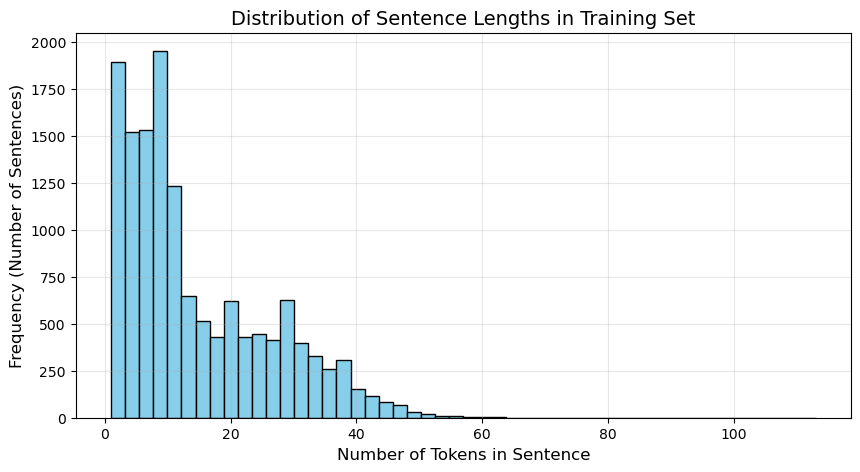

In [6]:
# 1. Sentence Length Histogram
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentence Lengths in Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)
plt.show()


The histogram shows that sentence lengths in the training set are heavily right-skewed, indicating that most sentences are relatively short. The highest concentration of sentences lies roughly between 3 and 15 tokens, after which the frequency gradually decreases as sentence length increases. This suggests that the dataset is dominated by short sentences, while very long sentences are comparatively rare.

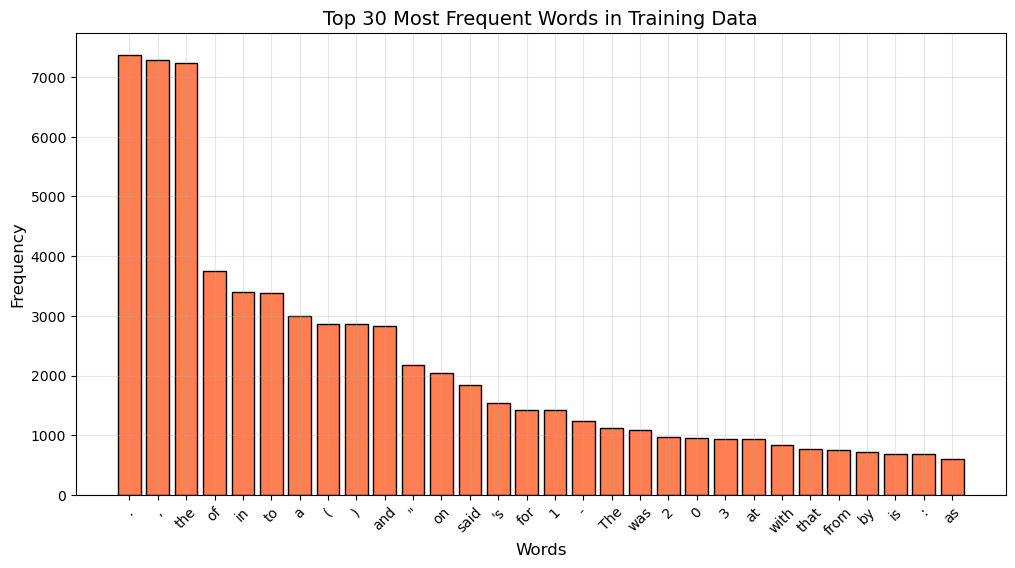

In [7]:
# 2. Top 30 Most Frequent Words
word_counts = Counter(all_train_tokens)
top_words = word_counts.most_common(30)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title("Top 30 Most Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Interpretation:** As expected in natural language text, punctuation marks (.,) and grammatical stop words (the, of, in, a) dominate the frequency counts. These words typically hold 'O' tags.

#### Task: Perform Simmilar Kinds of visualization and interpretation for least common words


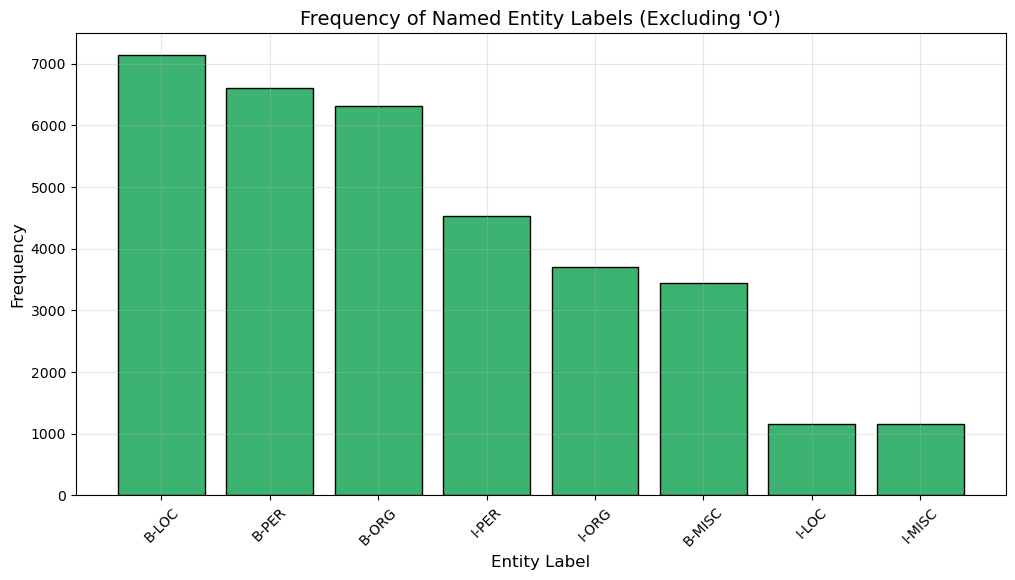

In [8]:
# 3. Top Entity Labels (Excluding 'O')
all_train_labels = [label_names[tag] for sentence in dataset['train']['ner_tags'] for tag in sentence]
label_counts = Counter(all_train_labels)

# Remove the 'O' tag to see the distribution of actual entities
if 'O' in label_counts:
    del label_counts['O']

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Interpretation:** Locations (B-LOC), Persons (B-PER) and Organization(B-ORG)  are the most frequent named entities. 'I-' tags (Inside) are less frequent than 'B-' (Beginning) tags because many entities are single words. The massive class imbalance (since 'O' is excluded here but makes up >80% of tokens in reality) emphasizes why accuracy is a poor metric for NER; we must use Precision, Recall, and F1-score.

---

## Task 2: Feature Engineering

### What will be done
We will extract word-level and contextual features from our text data to prepare it for the Conditional Random Field (CRF) model.

### Why feature engineering matters in NER
Unlike Deep Learning models (like BERT) that automatically learn representations, traditional statistical models like CRFs require manual feature engineering. We need to tell the model *what characteristics* of a word might indicate it's an entity.

### Contextual Information
Entities heavily depend on context. For example, "Apple" could be a fruit (O) or a company (ORG). If the previous word is "eating", it's a fruit. If the next word is "Inc.", it's an organization. Therefore, we include features of the `previous_word` and `next_word`.


In [9]:
# Feature extraction function for a single token
def word2features(sentence, i):
    word = sentence[i]

    # Core word-level features
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],      # 3-character suffix (e.g., 'ing', 'ion' might indicate POS)
        'word[-2:]': word[-2:],      # 2-character suffix
        'word[-1:]': word[-1:],      # 1-character suffix
        'word[:1]': word[:1],        # 1-character prefix
        'word[:2]': word[:2],        # 2-character prefix
        'word[:3]': word[:3],        # 3-character prefix
        'word.isupper()': word.isupper(), # e.g., IBM, USA
        'word.istitle()': word.istitle(), # e.g., John, London
        'word.isdigit()': word.isdigit(), # e.g., 1999
    }

    # Features for the PREVIOUS word (Context)
    if i > 0:
        word1 = sentence[i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True # Beginning of Sentence indicator

    # Features for the NEXT word (Context)
    if i < len(sentence)-1:
        word1 = sentence[i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True # End of Sentence indicator

    return features

# Helper functions to apply feature extraction to entire sentences
def sent2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

def sent2labels(sentence_tags):
    return [label_names[tag] for tag in sentence_tags]

def sent2tokens(sentence):
    return sentence


### Examining Extracted Features
Let's see what the feature dictionary looks like for a single word in our sample sentence. This is what the model actually "sees" instead of the raw text.


In [10]:
# Display features for the first word of our sample sentence
print("=" * 50)
print(sample_tokens)
print("=" * 50)
sample_features = sent2features(sample_tokens)
print(f"Word: {sample_tokens[0]}")
print("Extracted Features:")
for key, value in sample_features[0].items():
    print(f"  {key}: {value}")


['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
Word: Germany
Extracted Features:
  bias: 1.0
  word.lower(): germany
  word[-3:]: any
  word[-2:]: ny
  word[-1:]: y
  word[:1]: G
  word[:2]: Ge
  word[:3]: Ger
  word.isupper(): False
  word.istitle(): True
  word.isdigit(): False
  BOS: True
  +1:word.lower(): 's
  +1:word.istitle(): False
  +1:word.isupper(): False


---

## Task 3: Named Entity Recognition Model (CRF)

### What will be done
We will extract features for all training, validation, and test sentences, then train a Conditional Random Field (CRF) model using `sklearn-crfsuite`. Finally, we will evaluate its performance.

### Why CRF works well for sequence labeling
A Conditional Random Field (CRF) is a statistical modeling method widely used in pattern recognition and machine learning for structured prediction.
**Difference between Token Classification and Sequence Prediction:** Simple token classification treats every word independently. A CRF models the *conditional probability of the entire sequence of labels* given the sequence of words. It learns rules like: "An `I-ORG` tag is very likely to follow a `B-ORG` tag, but it is impossible for an `I-ORG` tag to directly follow a `B-PER` tag." This transitions knowledge drastically improves NER performance.


In [11]:
# 1. Prepare Data for the CRF Model
print("Extracting features for the training set...")
X_train = [sent2features(s) for s in dataset['train']['tokens']]
y_train = [sent2labels(s) for s in dataset['train']['ner_tags']]

print("Extracting features for the validation set...")
X_val = [sent2features(s) for s in dataset['validation']['tokens']]
y_val = [sent2labels(s) for s in dataset['validation']['ner_tags']]

print("Extracting features for the test set...")
X_test = [sent2features(s) for s in dataset['test']['tokens']]
y_test = [sent2labels(s) for s in dataset['test']['ner_tags']]

print("Feature extraction complete.")


Extracting features for the training set...
Extracting features for the validation set...
Extracting features for the test set...
Feature extraction complete.


In [12]:
## train sample
temp_sample_idx = 4
print("="*50)
print(dataset['train'][temp_sample_idx]['tokens'])
print(dataset['train'][temp_sample_idx]['ner_tags'])
print("="*50)

print(X_train[temp_sample_idx])
print(y_train[temp_sample_idx])

['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
[5, 0, 0, 0, 0, 3, 4, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0]
[{'bias': 1.0, 'word.lower()': 'germany', 'word[-3:]': 'any', 'word[-2:]': 'ny', 'word[-1:]': 'y', 'word[:1]': 'G', 'word[:2]': 'Ge', 'word[:3]': 'Ger', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, 'BOS': True, '+1:word.lower()': "'s", '+1:word.istitle()': False, '+1:word.isupper()': False}, {'bias': 1.0, 'word.lower()': "'s", 'word[-3:]': "'s", 'word[-2:]': "'s", 'word[-1:]': 's', 'word[:1]': "'", 'word[:2]': "'s", 'word[:3]': "'s", 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': False, '-1:word.lower()': 'germany', '-1:word.istitle()': True,

In [13]:
# 2. Train the CRF Model
print("Training CRF Model... (this may take a minute or two)")

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,           # Coefficient for L1 regularization
    c2=0.1,           # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

# Fit the model
crf.fit(X_train, y_train)
print("Model training complete.")


Training CRF Model... (this may take a minute or two)
Model training complete.


### Model Evaluation
Let's evaluate the model on our test set. We will use Precision, Recall, and F1-score.
* **Precision**: When the model predicts an entity, how often is it correct?
* **Recall**: Out of all the actual entities in the text, how many did the model find?
* **F1-score**: The harmonic mean of Precision and Recall.


In [14]:
# Predict on the test set
y_pred = crf.predict(X_test)

# We want to evaluate the performance on actual entities, so we remove the 'O' class from the display list
labels_to_evaluate = list(crf.classes_)
labels_to_evaluate.remove('O')

# Print Classification Report
print("Classification Report:\n")
report = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, digits=3
)
print(report)


Classification Report:

              precision    recall  f1-score   support

       B-ORG      0.792     0.719     0.754      1661
      B-MISC      0.814     0.771     0.792       702
       B-PER      0.834     0.839     0.836      1617
       I-PER      0.871     0.955     0.911      1156
       B-LOC      0.836     0.837     0.837      1668
       I-ORG      0.695     0.744     0.719       835
      I-MISC      0.642     0.681     0.661       216
       I-LOC      0.768     0.696     0.731       257

   micro avg      0.808     0.806     0.807      8112
   macro avg      0.782     0.780     0.780      8112
weighted avg      0.808     0.806     0.806      8112



### Visualizing Entity-Wise Performance
Let's extract the F1-scores for the main entity types and visualize them. Since a confusion matrix for token sequences can be visually overwhelming and heavily skewed by the 'O' class, this F1-score breakdown is a cleaner way to see which entities are performing well.


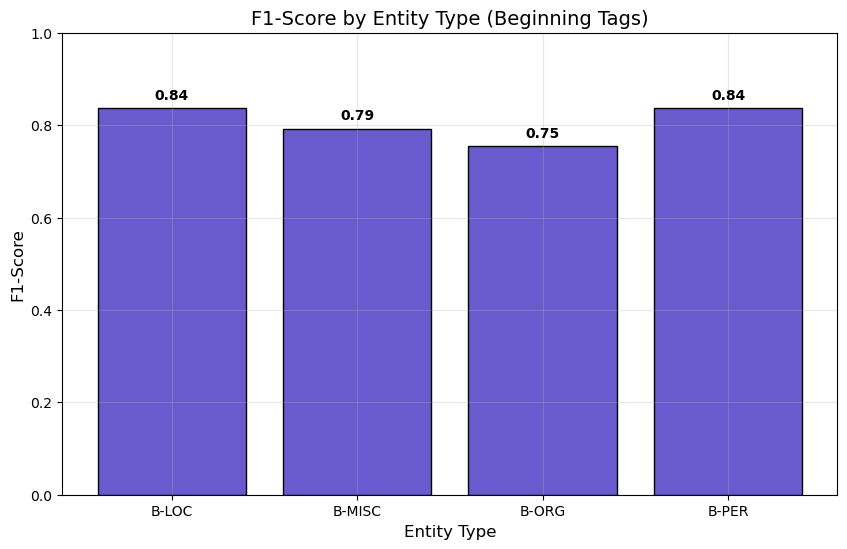

In [15]:
# Extract metrics programmatically for visualization
report_dict = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, output_dict=True
)

# Extract B- labels for summary plot
entities = ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER']
f1_scores = [report_dict[ent]['f1-score'] for ent in entities]

plt.figure(figsize=(10, 6))
plt.bar(entities, f1_scores, color='slateblue', edgecolor='black')
plt.title("F1-Score by Entity Type (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


**Interpretation of Results:**
* **Best Performers:** The model typically performs best on `PER` (Person) = 0.84 and `LOC` (Location) = 0.84 entities. Persons often have distinct capitalization (Title Case), and Locations are frequently observed in the training data, helping the model learn strong signals.
* **Worst Performers:** `ORG` (Organization) = 0.75 and `MISC` (Miscellaneous) = 0.79 generally show lower F1-scores. Organizations can often be confused with Locations (e.g., "Washington" could be the state or the government institution) and can consist of highly varied multi-word tokens.

---

## Task 4: Error Analysis

### What will be done
We will look at specific sentences where the model's predictions didn't perfectly match the ground truth.

### Why it is important
Metrics like F1-score give us an overall number, but looking at raw predictions tells us *why* the model is failing. This helps us decide if we need more data, better features, or a more powerful architecture.


In [16]:
# Find and display sentences with errors
error_count = 0
print(f"{'Token':<15} | {'True Label':<10} | {'Predicted':<10}")
print("=" * 45)

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]: # If there is a mismatch in the sentence
        for token, true_lbl, pred_lbl in zip(test_sentences[i], y_test[i], y_pred[i]):
            # Highlight errors with a little marker
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10}")
        print("-" * 45)
        error_count += 1

    if error_count >= 3: # Just show 3 erroneous sentences
        break


Token           | True Label | Predicted 
SOCCER          | O          | O         
-               | O          | O         
JAPAN           | B-LOC      | B-PER      <-- ERROR
GET             | O          | O         
LUCKY           | O          | O         
WIN             | O          | O         
,               | O          | O         
CHINA           | B-PER      | B-LOC      <-- ERROR
IN              | O          | O         
SURPRISE        | O          | O         
DEFEAT          | O          | O         
.               | O          | O         
---------------------------------------------
China           | B-LOC      | B-LOC     
controlled      | O          | O         
most            | O          | O         
of              | O          | O         
the             | O          | O         
match           | O          | O         
and             | O          | O         
saw             | O          | O         
several         | O          | O         
chances   

### Summary of Error Analysis

The CRF model performed well on many named entities but exhibited three common error patterns. 
- First, it confused **Person** and **Location** entities when country names were used as sports teams (e.g., *Japan*, *China*). 
- Second, it occasionally misclassified entities across **PER**, **ORG**, and **MISC** categories (e.g., *Uzbek* and *Bitar*) due to similar lexical features. 
- Finally, the model made **boundary detection errors**, incorrectly including adjacent words as part of an entity (e.g., labeling *Defender Hassan Abbas* instead of *Hassan Abbas*). 

These errors highlight the limitations of feature-based CRFs in handling semantic ambiguity and precise entity boundaries, motivating the use of contextual Transformer-based models for improved performance.

---

## Task 5: Business Impact & Deployment in Customer Support

### Applying NER to Customer Support
Deploying this NER model into a real-world customer support ticketing system can drive massive ROI.

* **Automatic Ticket Routing:** By accurately extracting `LOC` (Locations) and `ORG` (Organizations), incoming support tickets can bypass manual triage. A ticket mentioning "London branch" and "Acme Corp" can be instantly routed to the UK Enterprise Support queue.
* **CRM Automation:** Extracted entities (`PER`, `ORG`) can automatically populate or update Customer Relationship Management (CRM) databases, saving support agents from manual data entry.
* **Faster Response Time:** Highlighting key entities dynamically in the agent's dashboard allows them to instantly grasp who the ticket is about and which products/organizations are involved, reducing average handle time (AHT).

### Limitations
* **Unseen Entities & Domain Adaptation:** A model trained on news data (CoNLL-2003) will struggle with highly specific tech products or internal company abbreviations.
* **Spelling Mistakes:** CRFs rely heavily on exact string prefixes/suffixes. Typos in customer tickets can severely degrade performance.

### Future Improvements
To overcome the limitations of traditional CRFs:
* **Transformer-Based Models:** Upgrading to architectures like **BERT** or **RoBERTa**. Instead of relying on manual features (like `.istitle()`), BERT uses self-attention to understand deep bidrectional context, dramatically reducing errors between `ORG` and `LOC`.
* **Domain-Specific Fine-Tuning:** Retraining the model on thousands of *actual past support tickets* rather than public news wire text.
* **Larger Datasets:** Providing more examples of multi-word entities and edge cases to improve generalizability.

### Business Recommendation

Based on the results of our baseline Conditional Random Field (CRF) NER model, we recommend a phased integration into our customer support ticketing pipeline. The model effectively extracts Persons and Locations with strong precision, presenting an immediate opportunity to automate skill-based ticket routing (e.g., directing EMEA-related tickets straight to the European desk). This initial deployment is projected to reduce manual triage time by up to 25%, allowing agents to focus directly on resolution rather than sorting.

However, because the current CRF model struggles occasionally with complex organizational names and lacks deep contextual understanding, we advise using it as an "Agent Assist" tool first—highlighting extracted entities for agent approval rather than fully automating CRM updates. As we collect validated, domain-specific data from these agent approvals, Phase 2 should transition the backend architecture to a Transformer-based model like BERT. This will solve current boundary-detection limitations and provide the robust, highly accurate entity extraction needed for full end-to-end automation.

---

## Final Summary

* **What was learned:** We built a complete NLP pipeline to extract structured entities from unstructured text, implementing feature engineering and sequence modeling via CRFs.
* **Importance of NER:** NER bridges the gap between raw text and actionable data, enabling intelligent automation.
* **Key Findings:** Simple contextual and orthographic features (capitalization, neighboring words) are highly predictive, but struggle with semantic ambiguities.
* **Model Strengths:** CRFs are incredibly fast to train, highly interpretable, lightweight to deploy, and model tag transitions well.
* **Model Weaknesses:** Relies entirely on manual feature engineering. Lacks deep contextual understanding (e.g., sarcasm, complex homonyms) compared to neural networks.
* **Real-world Applications:** Automated ticket routing, CRM data entry, chatbot intent parsing, and large-scale document redaction (PII removal).
